In [1]:
import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
matplotlib.use('Agg')

from dataclasses import dataclass
from torch.distributions import Gamma, Multinomial, Dirichlet, Beta, Binomial
from tqdm.auto import tqdm

import os
import sys
from path import Path
current_directory = os.getcwd()
parent_directory = Path(current_directory).parent
sys.path.append(parent_directory)
from apf.base.sample import Sampler
from GS_DPGM import HGPDR,config,CRT
%load_ext Cython
%load_ext autoreload
%autoreload 2

# The easiest situation: deep=1

In [2]:
from GS_PRGDS_Interval_Tensor import GS_PRGDS_tensor
V=12
T=300
sys = torch.zeros(T, V)
high_value = 50
low_value = 0
############# Stage 1 #############
sys[0:100, 0:4] = torch.poisson(high_value*torch.ones(100,4))        # 1st community
############# Stage 2 #############
sys[100:200, 4:8] = torch.poisson(high_value*torch.ones(100,4))        # 2st community
############# Stage 3 #############
sys[200:300, 8:12] = torch.poisson(high_value*torch.ones(100,4))        # 3st community

burnin = 60
maxiter = 20
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True
}
params['data'] = sys
params['K'] = 12
params['S'] = 60

gs_prgds = GS_PRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# design phi we could get correct estimation of intensity under K=3
gs_prgds.phi[0][:,:] = 0.
gs_prgds.phi[0][0:4,0:4] = 0.25
gs_prgds.phi[0][4:8,4:8] = 0.25
gs_prgds.phi[0][8:12,8:12] = 0.25
gs_prgds.pi  = torch.tile(gs_prgds.phi[0], (params['S'],1,1)) # torch.tile的对象必须是tensor
gs_prgds.pit = torch.tile(gs_prgds.phi[0], (T,1,1))
gs_prgds.D   = torch.ones(gs_prgds.K, gs_prgds.K)*10
for iter in tqdm(range(burnin+maxiter)):
    gs_prgds.sample_n()
    gs_prgds.sample_h()
    gs_prgds.sample_the()
    gs_prgds.sample_lam()
    gs_prgds.sample_delt()
    gs_prgds.sample_g()
    gs_prgds.sample_gam()
    gs_prgds.sample_beta()
    gs_prgds.sample_phi()
    gs_prgds.sample_pi()
    gs_prgds.sample_eta()
    gs_prgds.sample_tilde_hskk()
    gs_prgds.sample_Z()
    gs_prgds.sample_D()
    gs_prgds.sample_dpgm()

    if iter > burnin:
        esti_temp = gs_prgds.phi[0] @ torch.diag(gs_prgds.lam) @ (gs_prgds.the).T @ torch.diag(gs_prgds.delt)
        esti_steady.append(esti_temp.clone())
        transition_steady.append(gs_prgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 0.5726 seconds
sample_h took 1.8934 seconds
sample_the took 0.0069 seconds
sample_lam took 0.0005 seconds
sample_delt took 0.0005 seconds
sample_g took 0.0011 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0058 seconds
sample_pi took 0.0888 seconds
sample_eta took 0.0014 seconds
sample_tilde_hskk took 0.0101 seconds
sample_Z took 1.0815 seconds
sample_D took 0.0066 seconds
sample_dpgm took 0.6255 seconds
sample_n took 0.5576 seconds
sample_h took 1.7789 seconds
sample_the took 0.0021 seconds
sample_lam took 0.0004 seconds
sample_delt took 0.0004 seconds
sample_g took 0.0013 seconds
sample_gam took 0.0002 seconds
sample_beta took 0.0002 seconds
sample_phi took 0.0068 seconds
sample_pi took 0.0702 seconds
sample_eta took 0.0011 seconds
sample_tilde_hskk took 0.0273 seconds
sample_Z took 1.0856 seconds
sample_D took 0.0067 seconds
sample_dpgm took 0.6109 seconds
sample_n took 0.4930 seconds
sample_h took 1.2019 seconds
sample_the too

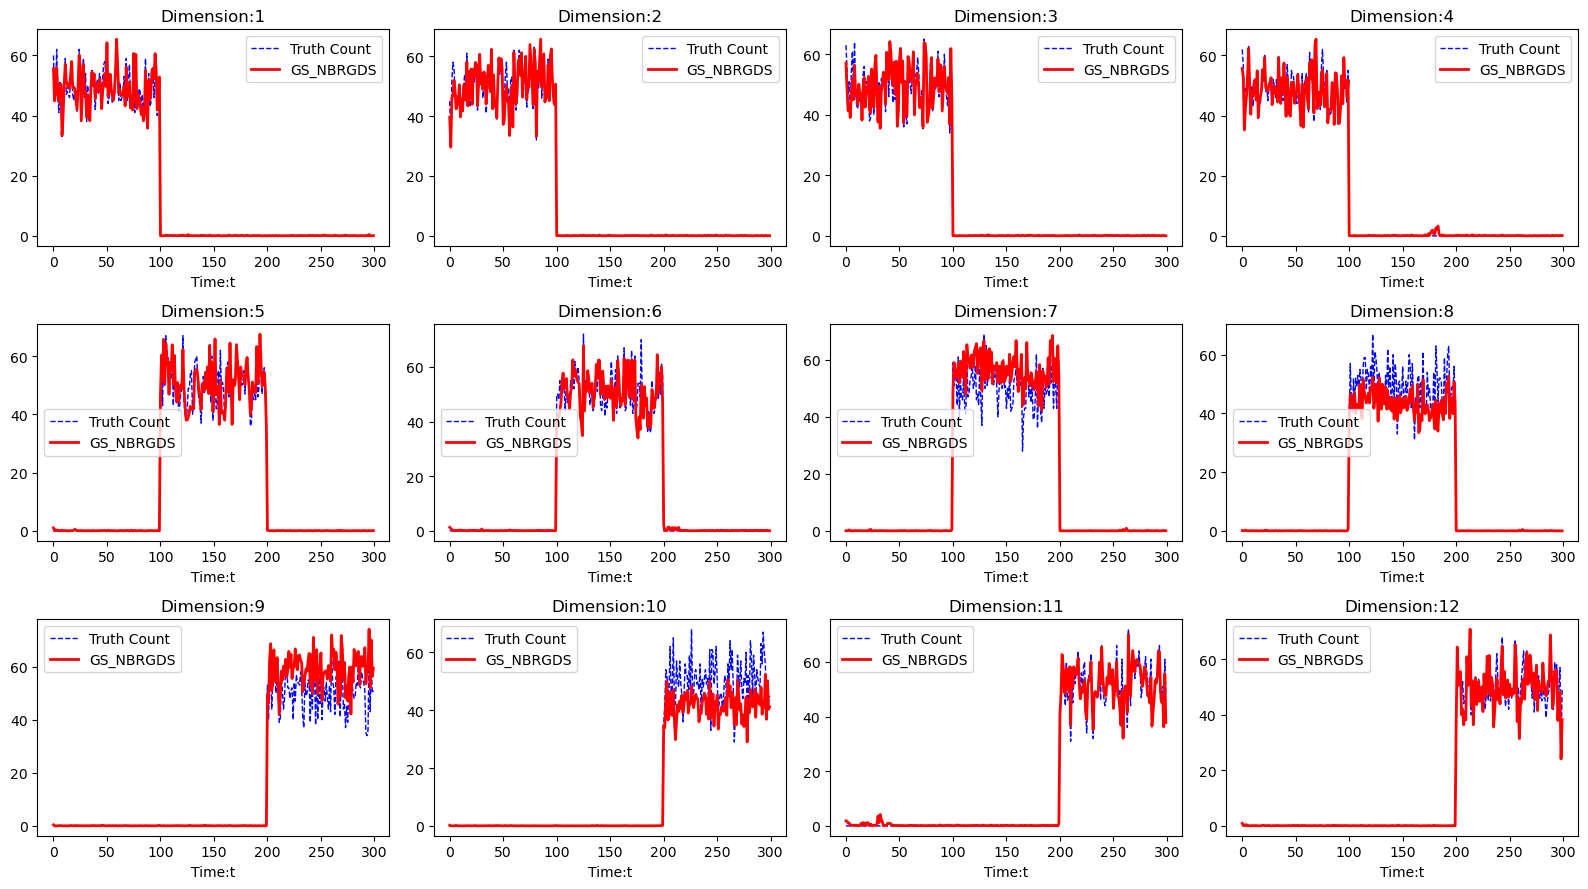

In [3]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
esti_steady = torch.stack(esti_steady)
esti_mean = torch.mean(esti_steady, axis = 0)
fig, axs = plt.subplots(3,4, figsize=(16,9))
for i, ax in enumerate(axs.flatten()):
    ax.plot(sys[:,i], color = 'blue', linewidth = 1, linestyle = '--', label = 'Truth Count')
    ax.plot(esti_mean[i], color = 'red', linewidth = 2, label = 'GS_NBRGDS')
    ax.set_title(f'Dimension:{i+1}')
    ax.set_xlabel('Time:t')
    ax.legend()
plt.tight_layout()
plt.show()

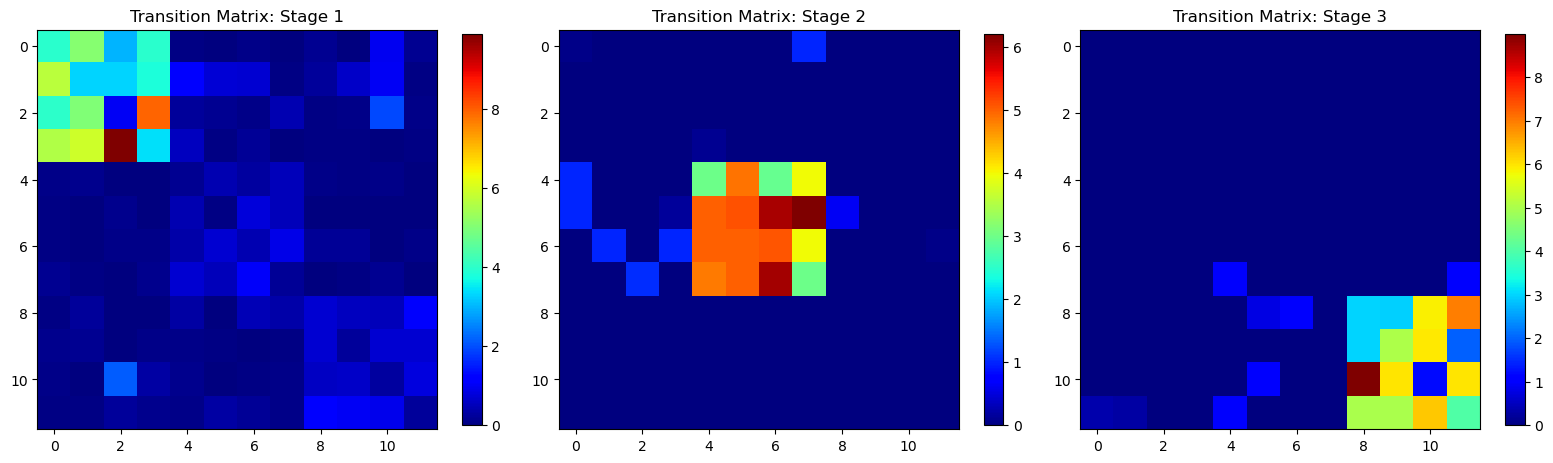

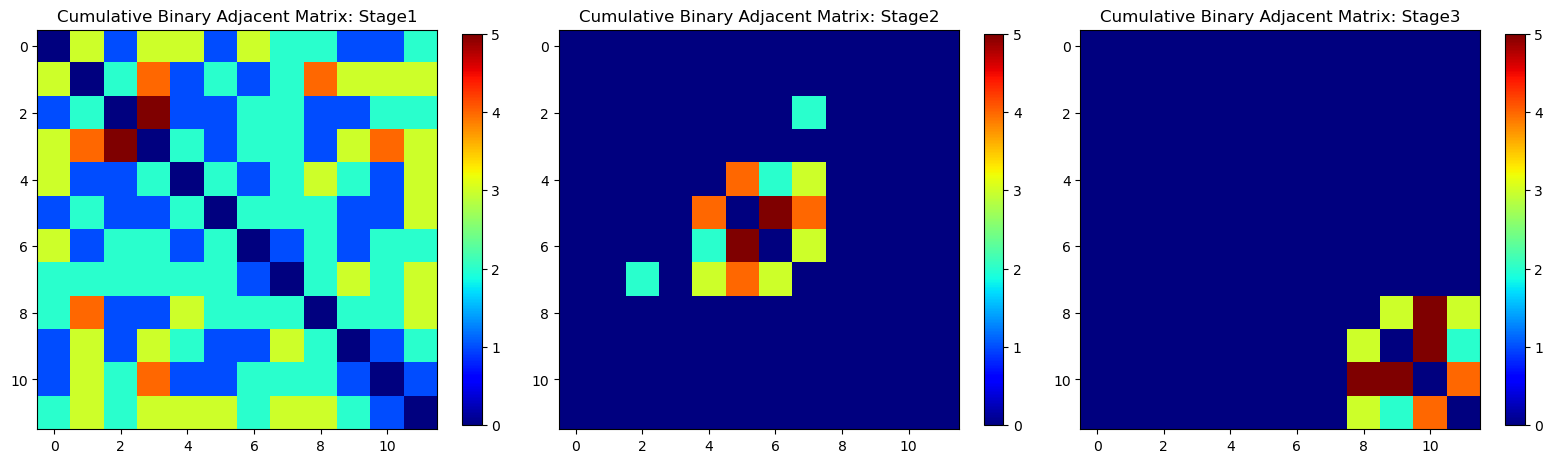

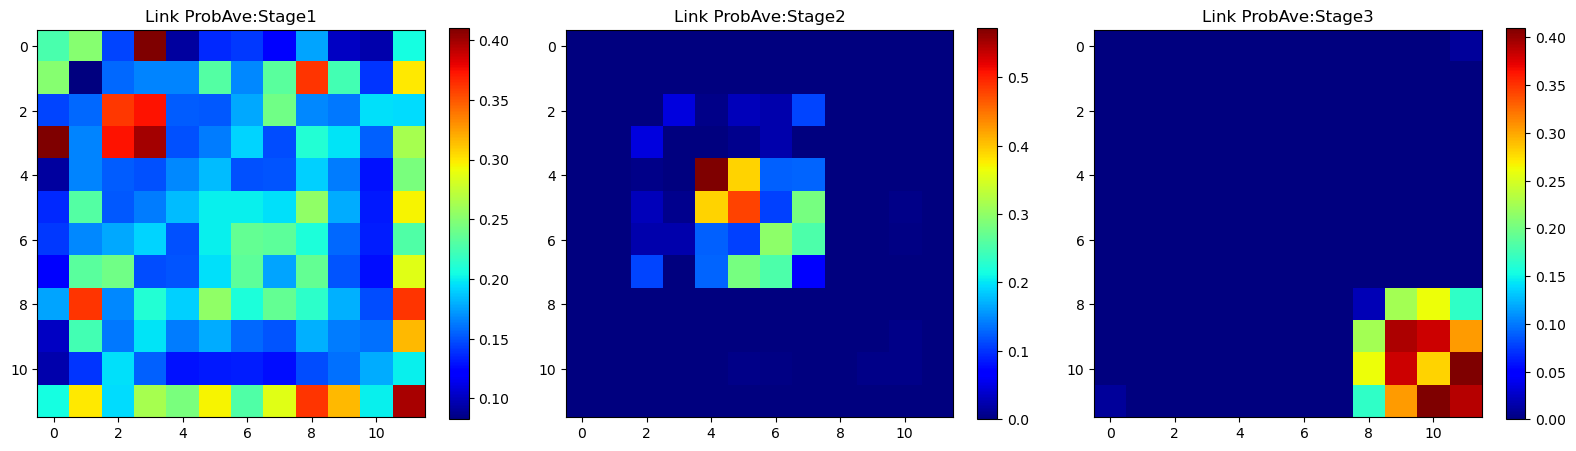

In [4]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 3, figsize=(16, 9))
for i, ax in enumerate(axs.flatten()):
    transition_sum = np.sum(np.array(transition_mean)[i*20: i*20+20], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Stage {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize=(16,9))
for i,ax in enumerate(axs):
    Z = torch.sum(gs_prgds.Z[i*20:i*20+20], axis=0)
    im = ax.imshow(Z+Z.T, cmap='jet')
    cbar = plt.colorbar(im, ax=ax, shrink=0.45)
    ax.set_title(f'Cumulative Binary Adjacent Matrix: Stage{i+1}')
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (16,9))
for i in range(3):
    ProbAve=torch.mean(gs_prgds.ProbAve[i*20:i*20+20], axis = 0) 
    im = axs[i].imshow(ProbAve + ProbAve.T, cmap='jet')
    axs[i].set_title(f'Link ProbAve:Stage{i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.45)
plt.tight_layout()
plt.show()

# Complex case

In [2]:
# complex case
# generate sysnthetic data
T = 1000
S = 5
high_value = 10
sys = torch.zeros(T,100,100)
# interval 1
sys[0:50, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[50:100, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[100:150, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[150:200, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 2 
sys[200:250, 20:40, 20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[250:300, 60:80, 60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[300:350, 20:40, 20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[350:400, 60:80, 60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 3
sys[400:450, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[400:450, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 4
sys[600:800, 20:40,20:40] = torch.poisson(high_value * torch.ones(200, 20, 20))
sys[600:800, 60:80,60:80] = torch.poisson(high_value * torch.ones(200, 20, 20))
# interval 5
sys[800:1000, 40:60, 40:60] = torch.poisson(high_value * torch.ones(200, 20, 20))

In [3]:
from GS_PRGDS_Interval_Tensor import GS_PRGDS_tensor
# run model
burnin = 60
maxiter = 20
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
'K' : 50, # latent components
'S' : 200, # sub-intervals
'parallel': True
}

gs_prgds = GS_PRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# phi should be a list
gs_prgds.phi[0][:,:] = 0.
gs_prgds.phi[0][0:20,0:10] = 1/20
gs_prgds.phi[0][20:40,10:20] = 1/20
gs_prgds.phi[0][40:60,20:30] = 1/20
gs_prgds.phi[0][60:80,30:40] = 1/20
gs_prgds.phi[0][80:100,40:50] = 1/20
gs_prgds.phi[1][:,:] = 0.
gs_prgds.phi[1][0:20,0:10] = 1/20
gs_prgds.phi[1][20:40,10:20] = 1/20
gs_prgds.phi[1][40:60,20:30] = 1/20
gs_prgds.phi[1][60:80,30:40] = 1/20
gs_prgds.phi[1][80:100,40:50] = 1/20

initial_pi = torch.zeros(50,50)
initial_pi[0:10, 0:10] = 1/10
initial_pi[10:20, 10:20] = 1/10
initial_pi[20:30, 20:30] = 1/10
initial_pi[30:40, 30:40] = 1/10
initial_pi[40:50, 40:50] = 1/10
gs_prgds.pi  = torch.tile(initial_pi, (params['S'],1,1))
gs_prgds.pit = torch.tile(initial_pi, (T,1,1))
gs_prgds.D   = torch.ones(gs_prgds.K, gs_prgds.K)*10

for iter in tqdm(range(burnin+maxiter)):
    gs_prgds.sample_n()
    gs_prgds.sample_h()
    gs_prgds.sample_the()
    gs_prgds.sample_lam()
    gs_prgds.sample_delt()
    gs_prgds.sample_g()
    gs_prgds.sample_gam()
    gs_prgds.sample_beta()
    gs_prgds.sample_phi()
    gs_prgds.sample_pi()
    gs_prgds.sample_eta()
    gs_prgds.sample_tilde_hskk()
    gs_prgds.sample_Z()
    gs_prgds.sample_D()
    gs_prgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(gs_prgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 179.4600 seconds
The total num of h_tk: tensor(0)
sample_h took 21.8711 seconds
sample_the took 0.0081 seconds
sample_lam took 0.0006 seconds
sample_delt took 0.0111 seconds
sample_g took 0.0035 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 1.6465 seconds
sample_pi took 1.0977 seconds
sample_eta took 0.0034 seconds
The total num of h_tkk:  tensor(66065)
sample_tilde_hskk took 0.1313 seconds
sample_Z took 0.0109 seconds
sample_D took 0.0046 seconds
sample_dpgm took 14.8410 seconds
sample_n took 171.1978 seconds
The total num of h_tk: tensor(66065)
sample_h took 21.5588 seconds
sample_the took 0.0103 seconds
sample_lam took 0.0005 seconds
sample_delt took 0.0134 seconds
sample_g took 0.0028 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 1.6446 seconds
sample_pi took 1.2316 seconds
sample_eta took 0.0042 seconds
The total num of h_tkk:  tensor(1717782)
sample_tilde_hskk took 5.6861 seconds
sampl

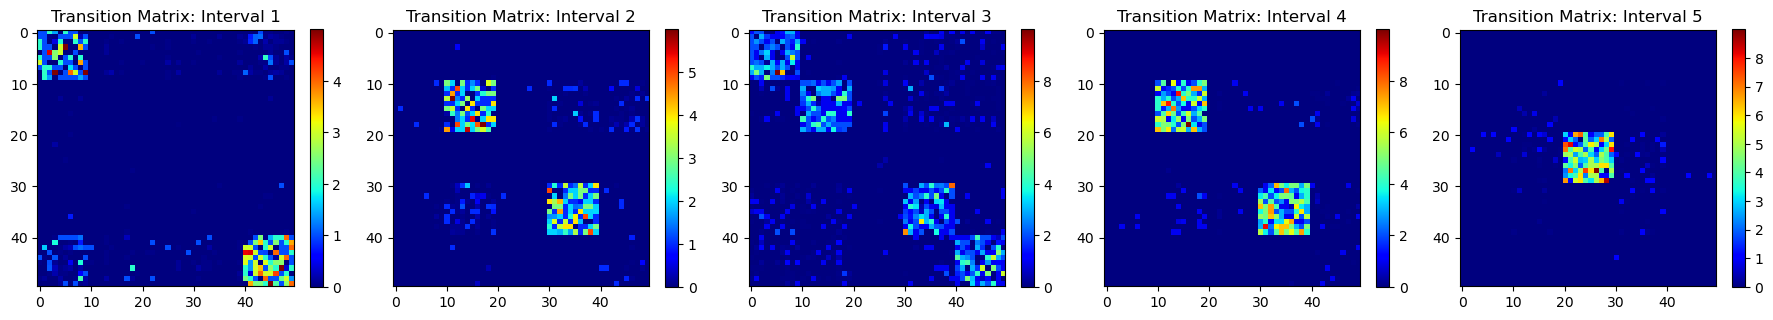

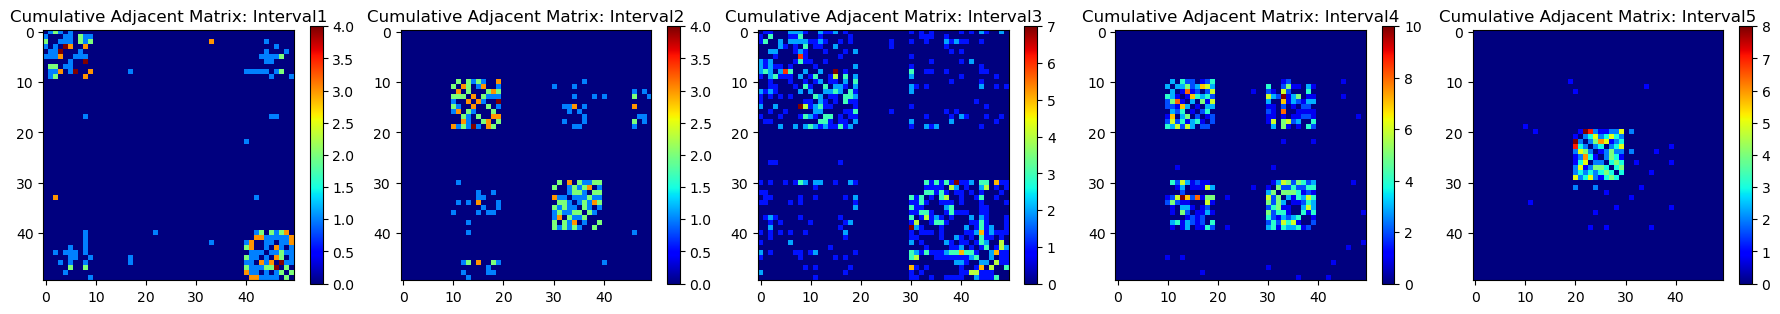

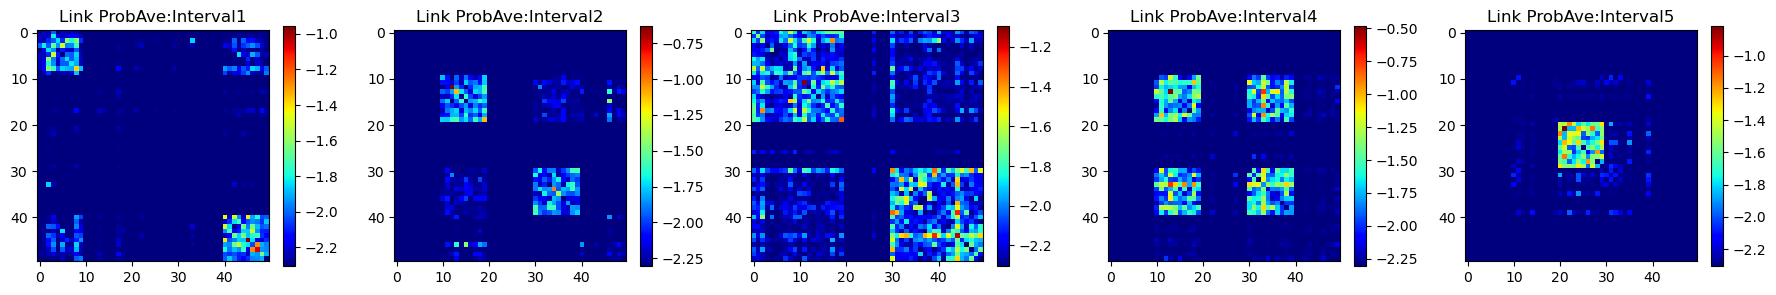

In [7]:
%matplotlib inline
#transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 5, figsize=(18,12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[8:40], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*40: i*40+40], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Interval {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.22)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,5, figsize=(18,12))
for i,ax in enumerate(axs.flatten()):
    if i == 0:
        Z = torch.sum(gs_prgds.Z[8:40], axis=0)
    else:
        Z = torch.sum(gs_prgds.Z[i*40:i*40+40], axis=0)
    im = ax.imshow(Z+Z.T, cmap='jet')
    cbar = plt.colorbar(im, ax=ax, shrink=0.22)
    ax.set_title(f'Cumulative Adjacent Matrix: Interval{i+1}')
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,5, figsize = (18,12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        ProbAve = torch.mean(gs_prgds.ProbAve[8:40], axis = 0)
    else:
        ProbAve = torch.mean(gs_prgds.ProbAve[i*40:i*40+40], axis = 0) 
    im = ax.imshow(torch.log(ProbAve + ProbAve.T + 0.1), cmap='jet')
    ax.set_title(f'Link ProbAve:Interval{i+1}')
    cbar = plt.colorbar(im, ax = ax, shrink=0.205)
plt.tight_layout()
plt.show()

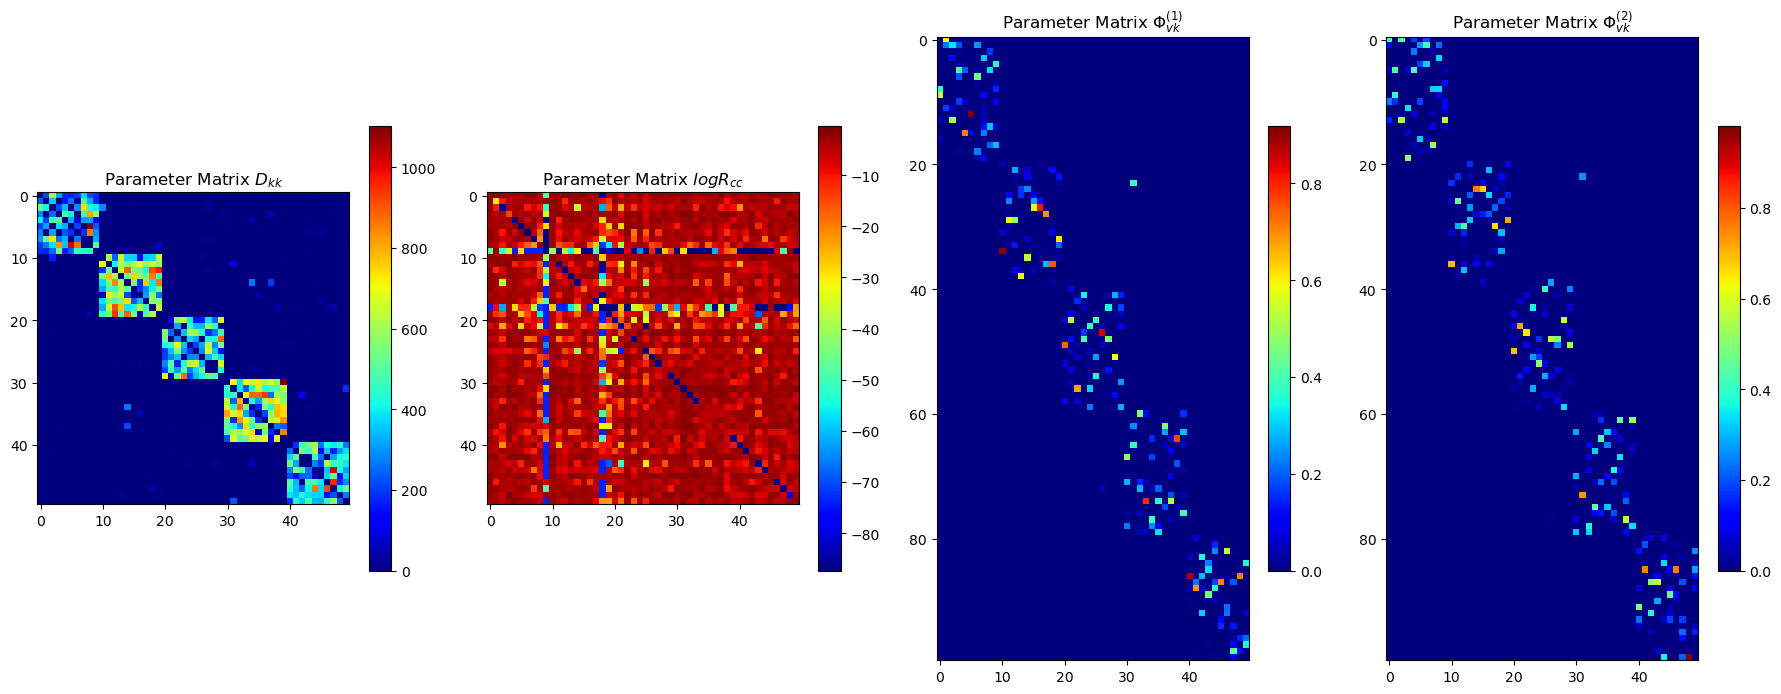

In [10]:
%matplotlib inline
fig, axs = plt.subplots(1,4, figsize = (18, 12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        im = ax.imshow(gs_prgds.D, cmap = 'jet')
        ax.set_title(r'Parameter Matrix $D_{kk}$')
        cbar = plt.colorbar(im, ax = ax, shrink = 0.38)
    elif i == 1:
        im = ax.imshow(torch.log(gs_prgds.dpgm_model.lam_kk), cmap = 'jet') # 用torch.log加强图像
        ax.set_title(r'Parameter Matrix $log R_{cc}$')
        cbar = plt.colorbar(im, ax = ax, shrink = 0.38)
    elif i == 2:
        im = ax.imshow(gs_prgds.phi[0], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(1)}$')
        cbar = plt.colorbar(im ,ax = ax, shrink = 0.38)
    elif i == 3:
        im = ax.imshow(gs_prgds.phi[1], cmap = 'jet')
        ax.set_title(r'Parameter Matrix $\Phi_{vk}^{(2)}$')
        char = plt.colorbar(im, ax = ax, shrink = 0.38)
plt.tight_layout()
plt.show()

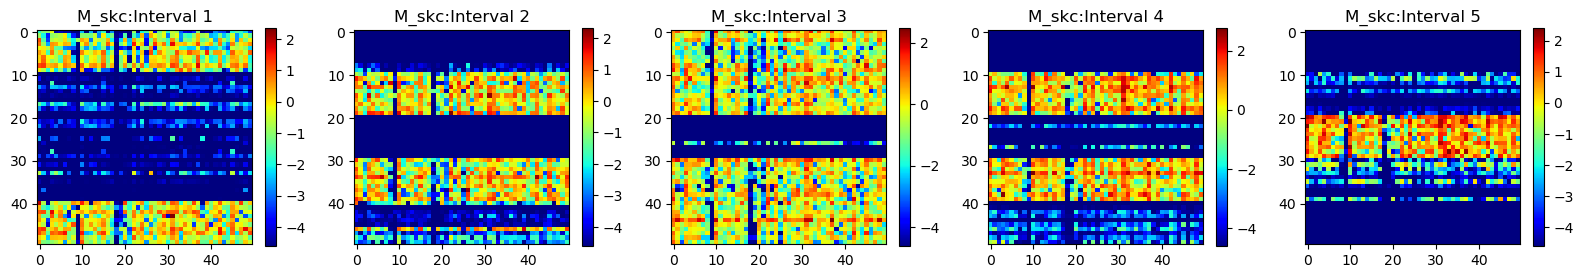

In [8]:
%matplotlib inline
fig, axs = plt.subplots(1,5, figsize = (16,9))
for i in range(5):
    if i == 0:
        dpgm_phi = torch.sum(gs_prgds.dpgm_model.phi[8:40], axis = 0)
    else:
        dpgm_phi = torch.sum(gs_prgds.dpgm_model.phi[i*40:i*40+40], axis = 0) 
    latent_feature = torch.log(dpgm_phi @ gs_prgds.dpgm_model.lam_kk + 0.01)
    im = axs[i].imshow(latent_feature, cmap='jet')
    axs[i].set_title(f'M_skc:Interval {i+1}')
    cbar = plt.colorbar(im, ax = axs[i], shrink=0.25)
plt.tight_layout()
plt.show()

# More complex case

In [2]:
# complex case
# generate sysnthetic data
T = 1000
S = 5
high_value = 10
sys = torch.zeros(T,100,100)
# interval 1
sys[0:50, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[50:100, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[100:150, 0:20, 0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[150:200, 80:100, 80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 2 
sys[200:250, 0:30, 0:30] = torch.poisson(high_value * torch.ones(50, 30, 30))
sys[250:300, 70:100, 70:100] = torch.poisson(high_value * torch.ones(50, 30, 30))
sys[300:350, 0:30, 0:30] = torch.poisson(high_value * torch.ones(50, 30, 30))
sys[350:400, 70:100, 70:100] = torch.poisson(high_value * torch.ones(50, 30, 30))
# interval 3
sys[400:450, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[400:450, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[450:500, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 0:20,0:20] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[500:550, 20:40,20:40] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 60:80,60:80] = torch.poisson(high_value * torch.ones(50, 20, 20))
sys[550:600, 80:100,80:100] = torch.poisson(high_value * torch.ones(50, 20, 20))
# interval 4
sys[600:800, 20:40,20:40] = torch.poisson(high_value * torch.ones(200, 20, 20))
sys[600:800, 60:80,60:80] = torch.poisson(high_value * torch.ones(200, 20, 20))
# interval 5
sys[800:1000, 40:60, 40:60] = torch.poisson(high_value * torch.ones(200, 20, 20))

In [3]:
from GS_PRGDS_Interval_Tensor import GS_PRGDS_tensor
# run model
burnin = 60
maxiter = 20
params = {
'tau': 1.,
'alpha0': 10.,
'epsilon_the': 0.1,
'epsilon_lam': 1.,
'stationary': True,
'data' : sys,
'K' : 50, # latent components
'S' : 200, # sub-intervals
'parallel': True
}

gs_prgds = GS_PRGDS_tensor(**params)
esti_steady = []
transition_steady = []
# phi should be a list
gs_prgds.phi[0][:,:] = 0.
gs_prgds.phi[0][0:20,0:10] = 1/20
gs_prgds.phi[0][20:40,10:20] = 1/20
gs_prgds.phi[0][40:60,20:30] = 1/20
gs_prgds.phi[0][60:80,30:40] = 1/20
gs_prgds.phi[0][80:100,40:50] = 1/20
gs_prgds.phi[1][:,:] = 0.
gs_prgds.phi[1][0:20,0:10] = 1/20
gs_prgds.phi[1][20:40,10:20] = 1/20
gs_prgds.phi[1][40:60,20:30] = 1/20
gs_prgds.phi[1][60:80,30:40] = 1/20
gs_prgds.phi[1][80:100,40:50] = 1/20

initial_pi = torch.zeros(50,50)
initial_pi[0:10, 0:10] = 1/10
initial_pi[10:20, 10:20] = 1/10
initial_pi[20:30, 20:30] = 1/10
initial_pi[30:40, 30:40] = 1/10
initial_pi[40:50, 40:50] = 1/10
gs_prgds.pi  = torch.tile(initial_pi, (params['S'],1,1))
gs_prgds.pit = torch.tile(initial_pi, (T,1,1))
gs_prgds.D   = torch.ones(gs_prgds.K, gs_prgds.K)*10

for iter in tqdm(range(burnin+maxiter)):
    gs_prgds.sample_n()
    gs_prgds.sample_h()
    gs_prgds.sample_the()
    gs_prgds.sample_lam()
    gs_prgds.sample_delt()
    gs_prgds.sample_g()
    gs_prgds.sample_gam()
    gs_prgds.sample_beta()
    gs_prgds.sample_phi()
    gs_prgds.sample_pi()
    gs_prgds.sample_eta()
    gs_prgds.sample_tilde_hskk()
    gs_prgds.sample_Z()
    gs_prgds.sample_D()
    gs_prgds.sample_dpgm()

    if iter > burnin:
        transition_steady.append(gs_prgds.pi.clone())

  0%|          | 0/80 [00:00<?, ?it/s]

sample_n took 182.2854 seconds
The total num of h_tk: tensor(0)
sample_h took 30.6513 seconds
sample_the took 0.0063 seconds
sample_lam took 0.0006 seconds
sample_delt took 0.0114 seconds
sample_g took 0.0045 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 1.8600 seconds
sample_pi took 1.4038 seconds
sample_eta took 0.0034 seconds
The total num of h_tkk:  tensor(66066)
sample_tilde_hskk took 0.1320 seconds
sample_Z took 0.0181 seconds
sample_D took 0.0046 seconds
sample_dpgm took 15.7514 seconds
sample_n took 205.9710 seconds
The total num of h_tk: tensor(66066)
sample_h took 27.5238 seconds
sample_the took 0.0077 seconds
sample_lam took 0.0005 seconds
sample_delt took 0.0118 seconds
sample_g took 0.0034 seconds
sample_gam took 0.0003 seconds
sample_beta took 0.0002 seconds
sample_phi took 1.9615 seconds
sample_pi took 1.1655 seconds
sample_eta took 0.0039 seconds
The total num of h_tkk:  tensor(2065069)
sample_tilde_hskk took 5.3804 seconds
sampl

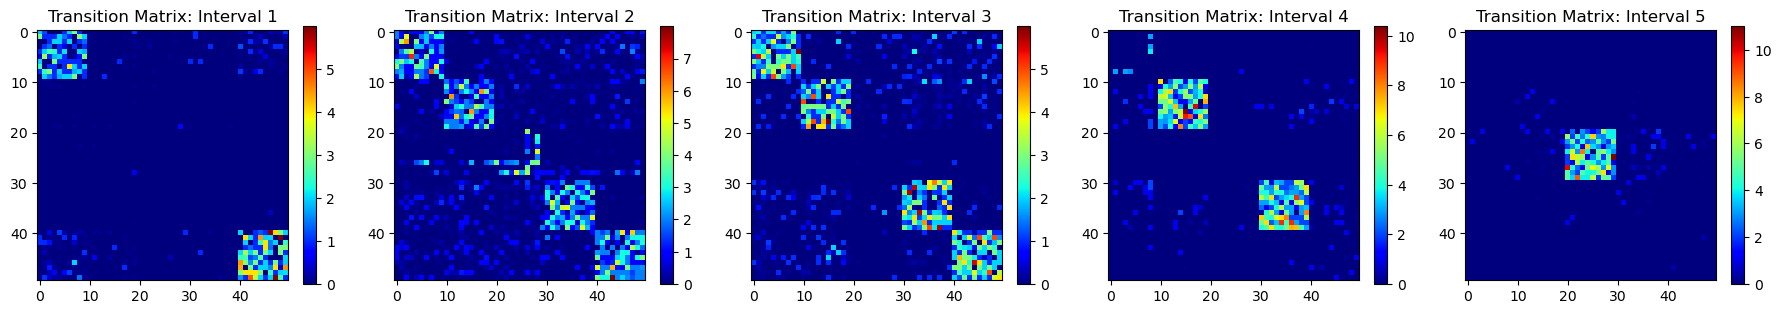

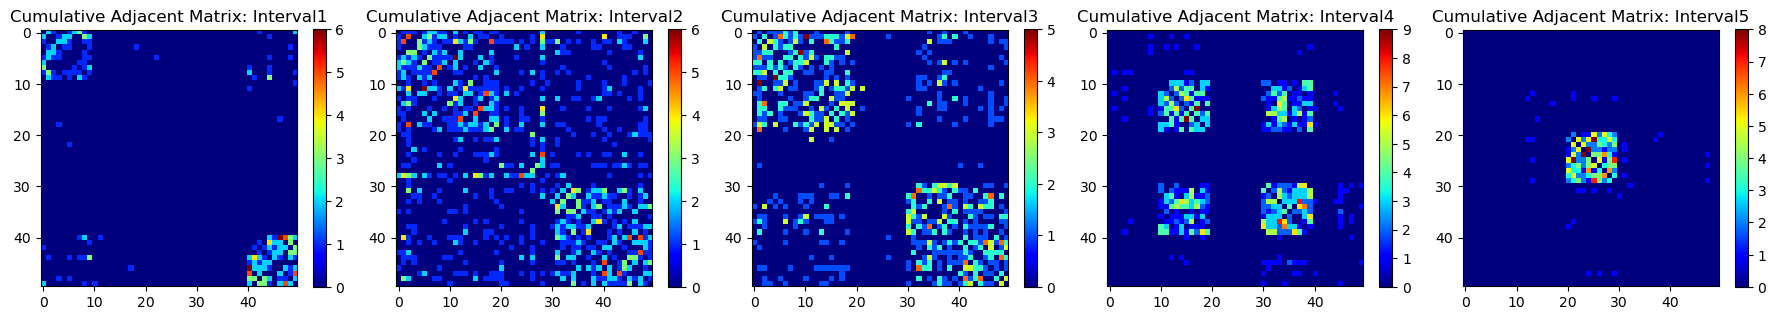

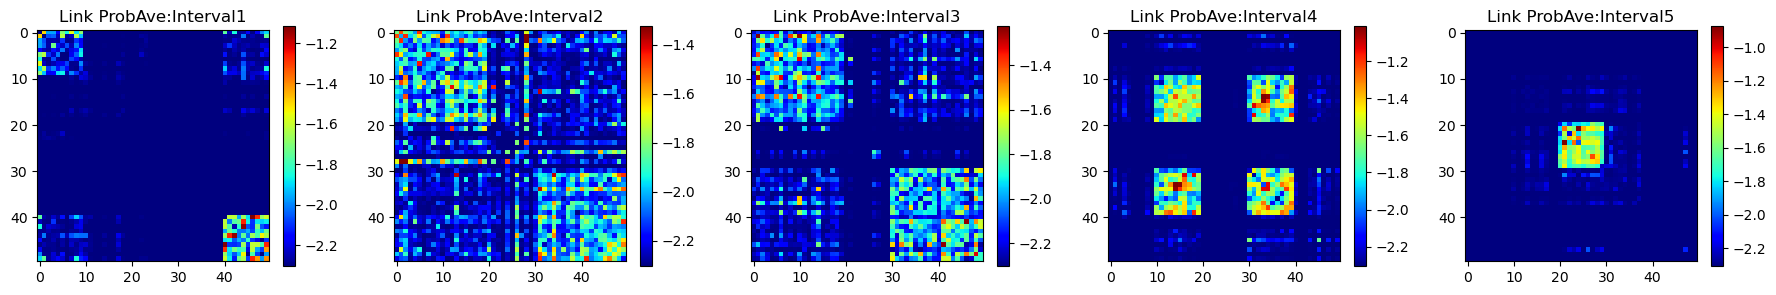

In [5]:
%matplotlib inline
transition_steady = torch.stack(transition_steady) 
transition_mean = torch.mean(transition_steady, axis = 0)
fig, axs = plt.subplots(1, 5, figsize=(18,12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        transition_sum = np.sum(np.array(transition_mean)[8:40], axis = 0)
    else:
        transition_sum = np.sum(np.array(transition_mean)[i*40: i*40+40], axis=0)
    im = ax.imshow(transition_sum, cmap='jet')
    ax.set_title(f'Transition Matrix: Interval {i+1}')
    # Add colorbar to each subplot
    cbar = plt.colorbar(im, ax=ax, shrink=0.22)
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,5, figsize=(18,12))
for i,ax in enumerate(axs.flatten()):
    if i == 0:
        Z = torch.sum(gs_prgds.Z[8:40], axis=0)
    else:
        Z = torch.sum(gs_prgds.Z[i*40:i*40+40], axis=0)
    im = ax.imshow(Z+Z.T, cmap='jet')
    cbar = plt.colorbar(im, ax=ax, shrink=0.22)
    ax.set_title(f'Cumulative Adjacent Matrix: Interval{i+1}')
plt.tight_layout()
plt.show()

%matplotlib inline
fig, axs = plt.subplots(1,5, figsize = (18,12))
for i, ax in enumerate(axs.flatten()):
    if i == 0:
        ProbAve = torch.mean(gs_prgds.ProbAve[8:40], axis = 0)
    else:
        ProbAve = torch.mean(gs_prgds.ProbAve[i*40:i*40+40], axis = 0) 
    im = ax.imshow(torch.log(ProbAve + ProbAve.T + 0.1), cmap='jet')
    ax.set_title(f'Link ProbAve:Interval{i+1}')
    cbar = plt.colorbar(im, ax = ax, shrink=0.205)
plt.tight_layout()
plt.show()